In [2]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import pandas as pd
from numpy.polynomial.hermite import hermgauss

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
import gc

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports

from src.xp_config import ExperimentConfig
from src.experiment import Experiment
from src.rg_integrator import rg_propagator

I run multiple "HOM experiment" with two incoming, undistinguishable photons with same frequency $\omega_p$, where $\omega_p \in [-\Gamma, \Gamma]$

In [3]:
#Physical parameters and cutoffs
omega_A = 10*np.pi
Gamma = 10*np.pi

lbda = 10*np.pi
cutoffs = {'ir_cutoff': omega_A - lbda, 'uv_cutoff': omega_A + lbda}

#Parameters of the simulation
L = 50

param_cavity = {'omega_0': omega_A, 'gamma': Gamma / (1 + Gamma / (np.pi*lbda)), 'L': L}

param_time_evol = {'T': L/2, 'dt': 0.01}

param_photons = {'omega_p': [omega_A - Gamma/2, omega_A - Gamma/2 ], 
                 'delta_k': [0.05*np.pi, 0.05*np.pi],
                 'x_0': [-L/4, -L/4]}

Frequency range and experiment

In [4]:
omega_p_tab = np.linspace(omega_A - 0.8*Gamma, omega_A + 0.8*Gamma, 15)
#omega_p_tab = [omega_A - Gamma/2, omega_A + Gamma/2]


coincidences = np.zeros(len(omega_p_tab))

for i, omega_p in enumerate(omega_p_tab):
    print("Treating experiment : ", i)
    param_photons['omega_p'] = [omega_p, omega_p]
    xp_config = ExperimentConfig(param_cavity=param_cavity,
                                 param_time_evol=param_time_evol,
                                 param_photons=param_photons,
                                 cutoffs=cutoffs)

    scattering_experiment = Experiment(xp_config)
    c_array, b1_array, b2_array = scattering_experiment.propagate_state(progress=True)

    #Compute only the observable of interest at final time
    n_modes = scattering_experiment.n_modes
    P12_final = np.sum(np.abs(scattering_experiment.c_array[-1, :n_modes, n_modes:])**2)
    P21_final = np.sum(np.abs(scattering_experiment.c_array[-1, n_modes:, :n_modes])**2)

    coincidences[i] = P12_final + P21_final

    del scattering_experiment
    del c_array, b1_array, b2_array
    gc.collect()

Treating experiment :  0


100%|██████████| 2499/2499 [02:06<00:00, 19.74it/s]


Treating experiment :  1


100%|██████████| 2499/2499 [02:07<00:00, 19.53it/s]


Treating experiment :  2


...

100%|██████████| 2499/2499 [02:48<00:00, 14.86it/s]


Treating experiment :  13


100%|██████████| 2499/2499 [02:45<00:00, 15.07it/s]


Treating experiment :  14


100%|██████████| 2499/2499 [02:10<00:00, 19.17it/s]


In [6]:
#Save the data
df = pd.DataFrame(coincidences)
filename=f"./csv_files/coincidence_benchmark.csv"
df.to_csv(filename)

Compare against predictions

In [21]:
#Monochromatic predicition
wp_theory = np.linspace(omega_A - 0.9*Gamma, omega_A + 0.9*Gamma, 100)
R_physical = 1 / (1 + ((wp_theory - omega_A)/ (Gamma/2))**2)
T_physical = 1 - R_physical

monochr_coincidence = 1 - 4*R_physical*T_physical

#Non monochr predicition: to be completed
inf = cutoffs['ir_cutoff']
sup = cutoffs['uv_cutoff']

def r(w):
    x = (w - omega_A )/(Gamma/2)
    return -1j / (x + 1j)

def t(w):
    x = (w - omega_A)/(Gamma/2)
    return x / (x + 1j)

def spectral_density(w, wp, dp):
    return (np.exp(-(w - wp)**2 / (2*dp**2))/ (np.sqrt(2*np.pi) * dp))

xs, ws = hermgauss(80)

def coincidence_non_monochr(wp):
    dp = param_photons['delta_k'][0]
    w = wp + dp*xs

    R = np.sum(ws * np.abs(r(w))**2) / np.sqrt(np.pi)
    I = np.sum(ws * t(w)*np.conj(r(w))) / np.sqrt(np.pi)

    T = 1 - R
    return T**2 + R**2 + 2*np.real(I**2)

coincidence_non_monochr_tab = np.array([coincidence_non_monochr(wp) for wp in wp_theory])

Figure

In [22]:
omega_p_tab = np.linspace(omega_A - 0.8*Gamma, omega_A + 0.8*Gamma, 15)
#omega_p_tab = [omega_A - Gamma/2, omega_A + Gamma/2]

coincidences = pd.read_csv("./csv_files/coincidence_benchmark.csv").to_numpy()
coincidences = coincidences[:, 1]

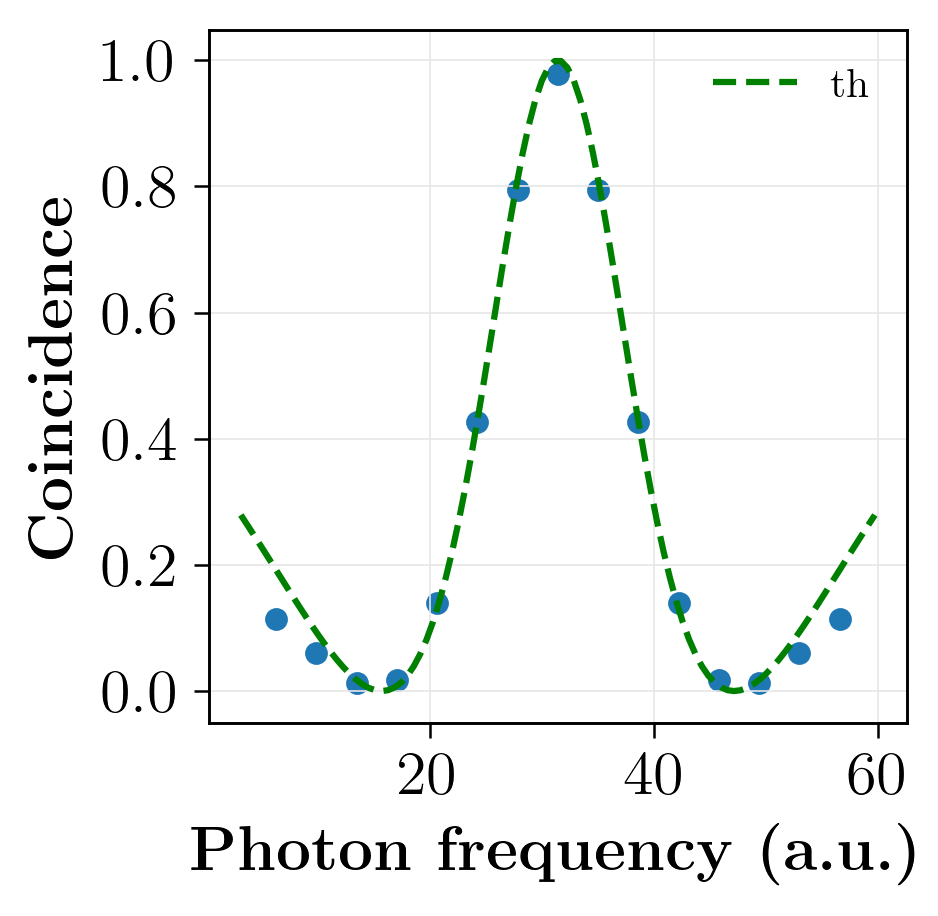

In [23]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)



# ---- courbes lisses ----
ax.scatter(omega_p_tab, coincidences, s=20)
#ax.plot(wp_theory, monochr_coincidence, color='black', linestyle='--')
ax.plot(wp_theory, coincidence_non_monochr_tab, color='green', linestyle='--', label='th')



# Labels, limites et grille
ax.set_xlabel(r'\textbf{Photon frequency (a.u.)}', fontsize=10)
ax.set_ylabel(r'\textbf{Coincidence}', fontsize=10)
ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Légende sobre
ax.legend(prop={'size': 10}, loc="best", frameon=False)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(15)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

plt.show()